# Notebook 02 - Extracción de imágenes de PDFs con PyMuPDF

En este notebook aprenderás a extraer imágenes incrustadas en archivos PDF. Esta técnica es útil para recuperar logotipos, gráficas, fotografías o figuras contenidas en reportes.

## ¿Por qué extraer imágenes?

Muchos PDFs contienen información visual que no puede obtenerse leyendo solo el texto:
- Reportes con gráficas
- Artículos científicos
- Facturas con códigos QR
- Manuales con diagramas

PyMuPDF permite acceder directamente a las imágenes embebidas sin necesidad de hacer capturas de pantalla.

In [2]:
# Instalar una sola vez
# !pip install pymupdf pillow

import fitz  # PyMuPDF
from PIL import Image
import io
import os

## Abrir un PDF

In [5]:
pdf=fitz.open("4.2 campusPue.pdf")
print("Páginas:",len(pdf))

Páginas: 1


`fitz.open()` carga el documento en memoria para poder recorrer cada página.

## Obtener las imágenes de una página

In [6]:
pagina=pdf[0]
imagenes=pagina.get_images(full=True)
print("Imágenes encontradas:",len(imagenes))
imagenes

Imágenes encontradas: 2


[(4, 8, 2077, 1169, 8, 'DeviceRGB', '', 'Im4', 'DCTDecode', 0),
 (5, 6, 1190, 670, 8, 'DeviceRGB', '', 'Im5', 'DCTDecode', 0)]

Cada elemento contiene metadatos. El primer valor (`xref`) identifica de forma única a la imagen dentro del PDF.

In [7]:
os.makedirs("imagenes_pdf",exist_ok=True)

for i,img in enumerate(imagenes, start=1):
    xref=img[0]
    base=pdf.extract_image(xref)
    datos=base["image"]
    ext=base["ext"]
    nombre=f"imagenes_pdf/pagina1_img{i}.{ext}"
    with open(nombre,"wb") as f:
        f.write(datos)
    print("Guardada:",nombre)

Guardada: imagenes_pdf/pagina1_img1.jpeg
Guardada: imagenes_pdf/pagina1_img2.jpeg


## Mostrar una imagen extraída

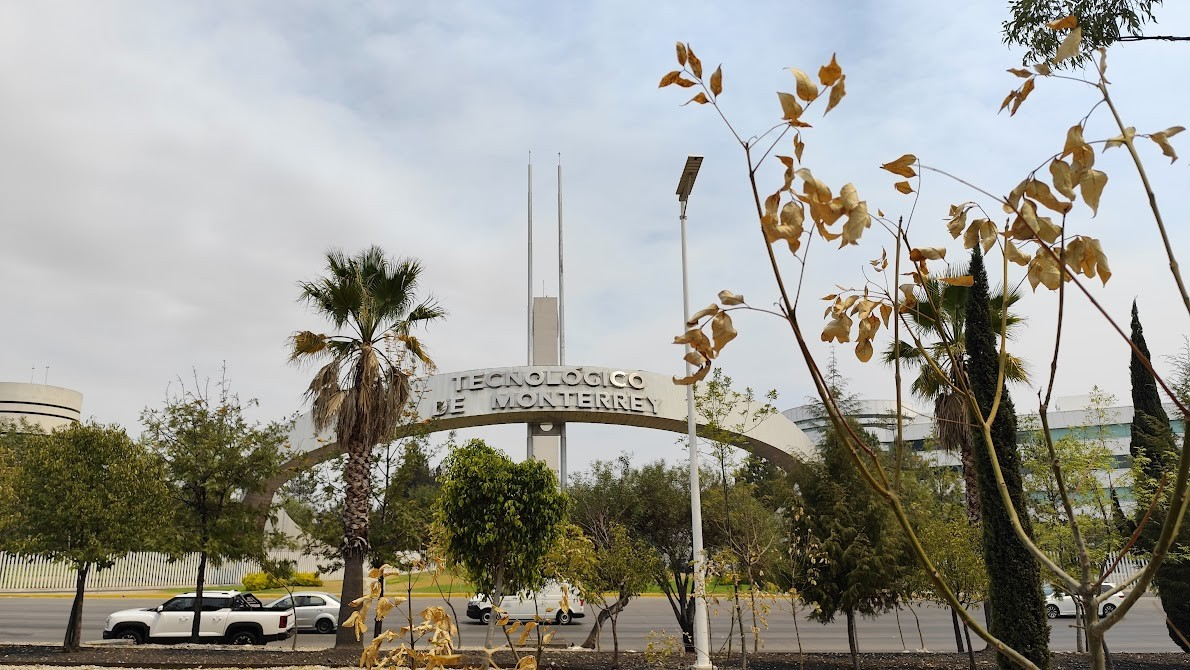

In [8]:
with open(nombre,"rb") as f:
    imagen=Image.open(io.BytesIO(f.read()))
imagen

## Extraer imágenes de todo el documento

In [9]:
contador=1
for n in range(len(pdf)):
    pagina=pdf[n]
    for img in pagina.get_images(full=True):
        xref=img[0]
        base=pdf.extract_image(xref)
        with open(f"imagenes_pdf/img_{contador}.{base['ext']}","wb") as f:
            f.write(base["image"])
        contador+=1
print("Total extraídas:",contador-1)

Total extraídas: 2


## Buenas prácticas

- Usa `os.makedirs()` para crear la carpeta de salida.
- Cierra el PDF cuando termines (`pdf.close()`).
- No todas las páginas contienen imágenes.
- Algunas imágenes pueden repetirse varias veces dentro del documento.

In [10]:
pdf.close()

## Ejercicio

1. Descarga un PDF con imágenes.
2. Extrae todas las imágenes.
3. Cuenta cuántas obtuvo cada página.
4. Identifica su formato (PNG, JPEG, etc.).

# Resumen para examen

- `fitz.open()` → abre el PDF.
- `page.get_images(full=True)` → lista las imágenes de una página.
- `extract_image(xref)` → obtiene los bytes de la imagen.
- `PIL.Image` → permite visualizar o procesar la imagen.
- Flujo: **PDF → Página → Imagen → Archivo → Análisis**.